<div align="center">

#  Predicción de brotes de dengue en Argentina
## Modelo de aprendizaje automático con variables climáticas y epidemiológicas

---

| | |
|---|---|
| **Integrantes** | *Balda Javier · Caracoix Juan · Casas Facundo* |
| **Institución** | *Universidad Católica Argentina* |
| **Materia / curso** | *Consultoría de datos: Laboratorio III* |
| **Fecha** | Abril 2026 |
| **Datos** | SNVS 2018–2025 (Ministerio de Salud, Argentina) + NASA POWER API |
| **Revista objetivo** | *Revista de Salud UIS* (Universidad Industrial de Santander, Colombia) |

</div>

##  Tabla de contenidos

1. [Objetivo del proyecto](#objetivo)
2. [Hipótesis y preguntas de investigación](#hipotesis)
3. [Estado del arte](#estado-del-arte)
4. [Revista objetivo](#revista)
5. [Configuración del entorno](#config)
6. [Ingesta de datos — SNVS](#snvs)
7. [Ingesta de datos — NASA POWER API](#nasa)
8. [Calidad y limpieza de datos](#limpieza)
9. [Dataset limpio — exportación](#exportacion)
10. [Análisis exploratorio (EDA)](#eda)
11. [Feature engineering](#features)
12. [Modelo baseline y modelo candidato](#modelos)
13. [Validación walk-forward](#validacion)
14. [Resultados e interpretabilidad](#resultados)

---
<a id="objetivo"></a>

##  1. Objetivo del proyecto

Este proyecto tiene como objetivo desarrollar un **modelo predictivo de brotes de dengue a nivel departamental en Argentina**, capaz de anticipar el número de casos confirmados con **2 a 4 semanas de anticipación**, utilizando exclusivamente datos de acceso público.

### Objetivo general

Construir y evaluar un sistema de alerta temprana basado en aprendizaje automático que integre series epidemiológicas semanales del SNVS (2018–2025), variables climáticas de NASA POWER y factores sociodemográficos del Censo 2022, para predecir la incidencia departamental de dengue en Argentina.

### Objetivos específicos

1. Integrar y normalizar datos heterogéneos provenientes de múltiples fuentes públicas (SNVS, NASA POWER, INDEC).
2. Construir un conjunto de features que capture rezagos epidemiológicos, climáticos y contexto socioeconómico.
3. Comparar el desempeño de modelos de referencia (media móvil, Random Forest, XGBoost) mediante validación walk-forward.
4. Evaluar el sistema sobre el brote 2024 —el más severo de la historia argentina— como test prospectivo.
5. Producir un mapa de alertas departamental actualizable semanalmente.

---
<a id="hipotesis"></a>

##  2. Hipótesis y preguntas de investigación

### Pregunta experimental principal

> ¿Es posible predecir el número de casos semanales de dengue por departamento con 2 a 4 semanas de anticipación, alcanzando un **MAPE ≤ 30 %** en departamentos con más de 100 casos históricos acumulados, usando variables climáticas rezagadas, índice de vegetación NDVI y casos previos, superando un baseline de media móvil histórica?

### Hipótesis principal

**H1:** Un modelo de ensamble (Random Forest / XGBoost) entrenado con lags epidemiológicos y variables climáticas rezagadas (t−2 a t−6 semanas) alcanza un MAPE significativamente menor que una media móvil de 4 semanas en departamentos con más de 100 casos históricos.

### Hipótesis secundarias

**H2:** La temperatura media rezagada 2–4 semanas es el predictor climático de mayor importancia, consistente con el ciclo de vida del *Aedes aegypti* (~14 días entre picadura y viremia).

**H3:** El índice NBI (Necesidades Básicas Insatisfechas) y la densidad poblacional mejoran la predicción al controlar heterogeneidad socioeconómica entre departamentos.

**H4:** El modelo entrenado en 2018–2023 generaliza al brote 2024 mejor que el baseline, demostrando capacidad predictiva en condiciones de brote sin precedentes.

### Preguntas adicionales de análisis

- ¿Qué lag temporal maximiza la correlación entre temperatura/precipitación y casos?
- ¿Existen diferencias regionales en la importancia de las variables climáticas (NOA vs. región pampeana vs. NEA)?
- ¿El modelo detecta el inicio del brote (alerta temprana binaria) con precisión suficiente para guiar operaciones de fumigación?

---
<a id="estado-del-arte"></a>

##  3. Estado del arte y marco conceptual

### 3.1 Epidemiología del dengue y contexto global

El dengue es la arbovirosis de mayor expansión a nivel mundial, con aproximadamente 390 millones de infecciones anuales en más de 100 países (Bhatt et al., 2013). La Organización Mundial de la Salud reporta que la incidencia global se multiplicó por diez entre 2000 y 2019. En América Latina, Brasil, Colombia, Argentina y México concentran la mayor carga de enfermedad. Argentina registró en 2024 su brote más severo, con 582.267 casos confirmados, lo que pone en evidencia la expansión del vector hacia latitudes históricamente no endémicas.

### 3.2 Modelos estadísticos clásicos

Los primeros enfoques predictivos se basaron en modelos de series temporales univariados. Luz et al. (2008) analizaron la incidencia de dengue en Río de Janeiro mediante modelos ARIMA, estableciendo una de las primeras referencias metodológicas para la región. Los modelos SARIMA y SARIMAX incorporan posteriormente la estacionalidad y variables climáticas exógenas (temperatura, humedad), mejorando la captura de patrones cíclicos. Racloz et al. (2012) revisaron sistemáticamente los modelos de vigilancia epidemiológica y señalaron que los enfoques univariados sub-representan la dinámica espacial y las interacciones entre variables.

### 3.3 Aprendizaje automático aplicado a la predicción de dengue

La incorporación de técnicas de machine learning marcó un punto de inflexión. Mussumeci y Coelho (2020) compararon modelos LSTM, Random Forest y regresión Lasso para predicción a gran escala en Brasil, encontrando que Random Forest ofrecía el mejor balance entre precisión y interpretabilidad para horizontes cortos (1–4 semanas). Roster et al. (2022) validaron modelos de machine learning en ciudades brasileñas usando variables epidemiológicas y meteorológicas, destacando que los modelos de ensamble superan a la regresión de Poisson en predicción de corto plazo. Salim et al. (2021) evaluaron SVM, árbol de decisión y redes neuronales para Selangor (Malasia), alcanzando 70% de precisión con SVM; sin embargo, los modelos de ensamble como XGBoost y Random Forest superaron a los clasificadores individuales (Patil y Pandya, 2021; Mazhar et al., 2024).

Sebastianelli et al. (2024) propusieron un enfoque de ensamble reproducible para Brasil, demostrando transferibilidad a Perú y estableciendo un marco metodológico aplicable a Argentina. Más recientemente, Jiménez et al. (2025) desarrollaron un modelo LSTM con SHAP para Brasil que integra lags climáticos y efectos espaciales entre estados vecinos, logrando predicciones a 4 y 12 semanas con ventanas deslizantes de 7 años de entrenamiento.

### 3.4 Variables climáticas y rezagos temporales

La temperatura es el predictor climático dominante en la biología del *Aedes aegypti*: el ciclo completo de vida (huevo → adulto) tarda aproximadamente 7–14 días a 25–30°C, mientras que el período de incubación extrínseca del virus se acorta drásticamente por encima de 30°C. Esto fundamenta el uso de rezagos climáticos de 2–6 semanas como features (Cabrera et al., 2022; Salim et al., 2021). La precipitación acumulada favorece la formación de criaderos, aunque con efectos no lineales: precipitaciones muy intensas pueden eliminar larvas por arrastre. Ochida et al. (2022) identificaron que la humedad relativa mínima y la temperatura máxima son los predictores climáticos de mayor importancia en contextos tropicales.

### 3.5 Revisiones sistemáticas recientes

Leung et al. (2023) realizaron la revisión sistemática más completa hasta la fecha sobre modelos de predicción de brotes de dengue, analizando 160 estudios. Concluyeron que los modelos de aprendizaje automático superan consistentemente a los métodos estadísticos clásicos, y que la incorporación de variables ambientales y satelitales (NDVI) mejora la precisión, especialmente para horizontes de 2–4 semanas. Sylvestre et al. (2022) identificaron en otra revisión sistemática que los datos de vigilancia epidemiológica combinados con variables meteorológicas constituyen la combinación de inputs más robusta. Mazhar et al. (2024) destacaron que los modelos basados en datos reales de vigilancia (como el SNVS de Argentina) superan a los modelos teóricos compartimentales (SIR/SEIR) en precisión operativa.

### 3.6 Vacío en la literatura y aporte de este trabajo

La mayoría de los estudios existentes se focalizan en Brasil, Colombia o países del sudeste asiático. **No se identificaron publicaciones que apliquen modelos de machine learning con validación walk-forward al sistema de vigilancia argentino (SNVS) utilizando datos departamentales reales**, ni que evalúen el brote 2024 como test prospectivo. Este trabajo busca cubrir ese vacío, constituyendo el primer análisis sistemático de predicción departamental de dengue en Argentina con datos reales 2018–2025.

---

### Referencias (formato APA 7.ª edición)

Bhatt, S., Gething, P. W., Brady, O. J., Messina, J. P., Farlow, A. W., Moyes, C. L., Drake, J. M., Brownstein, J. S., Hoen, A. G., Sankoh, O., Myers, M. F., George, D. B., Jaenisch, T., Wint, G. R. W., Simmons, C. P., Scott, T. W., Farrar, J. J., & Hay, S. I. (2013). The global distribution and burden of dengue. *Nature*, *496*(7446), 504–507. https://doi.org/10.1038/nature12060

Cabrera, M., Leake, J., Naranjo-Torres, J., Valero, N., Cabrera, J. C., & Rodríguez-Morales, A. J. (2022). When climate variables improve the dengue forecasting: A machine learning approach. *The European Physical Journal Special Topics*, *231*, 3473–3485. https://doi.org/10.1140/epjs/s11734-024-01201-7

Jiménez, L., Costa, G. P., & Silva, F. R. (2025). Forecasting dengue across Brazil with LSTM neural networks and SHAP-driven lagged climate and spatial effects. *BMC Public Health*, *25*, 892. https://doi.org/10.1186/s12889-025-22106-7

Leung, X. Y., Islam, R. M., Adhami, M., Ilic, D., McDonald, L., Palawaththa, S., Diug, B., Munshi, S. U., & Karim, M. N. (2023). A systematic review of dengue outbreak prediction models: Current scenario and future directions. *PLOS Neglected Tropical Diseases*, *17*(2), e0010631. https://doi.org/10.1371/journal.pntd.0010631

Luz, P. M., Mendes, B. V. M., Codeço, C. T., Struchiner, C. J., & Galvani, A. P. (2008). Time series analysis of dengue incidence in Rio de Janeiro, Brazil. *The American Journal of Tropical Medicine and Hygiene*, *79*(6), 933–939. https://doi.org/10.4269/ajtmh.2008.79.933

Mazhar, B., Mazhar Ali, N., Manzoor, F., Khan, M. K., Nasir, M., & Ramzan, M. (2024). Development of data-driven machine learning models and their potential role in predicting dengue outbreak. *Journal of Vector Borne Diseases*, *61*(4), 503–514. https://doi.org/10.4103/0972-9062.393976

Mussumeci, E., & Coelho, F. C. (2020). Large-scale multivariate forecasting models for dengue – LSTM versus random forest regression. *Spatial and Spatio-temporal Epidemiology*, *35*, 100372. https://doi.org/10.1016/j.sste.2020.100372

Ochida, N., Mangeas, M., Dupont-Rouzeyrol, M., Dutheil, C., Forfait, C., Peltier, A., Descloux, E., & Menkes, C. (2022). Identification of significant climatic risk factors and machine learning models in dengue outbreak prediction. *BMC Medical Informatics and Decision Making*, *21*, 141. https://doi.org/10.1186/s12911-021-01493-y

Patil, S., & Pandya, S. (2021). Forecasting dengue hotspots associated with variation in meteorological parameters using regression and time series models. *Frontiers in Public Health*, *9*, 798034. https://doi.org/10.3389/fpubh.2021.798034

Racloz, V., Ramsey, R., Tong, S., & Hu, W. (2012). Surveillance of dengue fever virus: A review of epidemiological models and early warning systems. *PLOS Neglected Tropical Diseases*, *6*(5), e1648. https://doi.org/10.1371/journal.pntd.0001648

Roster, K., Connaughton, C., & Rodrigues, F. A. (2022). Machine-learning–based forecasting of dengue fever in Brazilian cities using epidemiologic and meteorological variables. *American Journal of Epidemiology*, *191*(10), 1803–1812. https://doi.org/10.1093/aje/kwac090

Salim, N. A. M., Wah, Y. B., Reeves, C., Smith, M., Yaacob, W. F. W., Mudin, R. N., Dapari, R., Sapri, N. N. F. F., & Haque, U. (2021). Prediction of dengue outbreak in Selangor Malaysia using machine learning techniques. *Scientific Reports*, *11*, 939. https://doi.org/10.1038/s41598-020-79193-2

Sebastianelli, A., Spiller, D., Carmo, R., Wheeler, J., Nowakowski, A., Jacobson, L. V., Kim, D., Barlevi, H., Cordero, Z. E., Colón-González, F. J., & Lowe, R. (2024). A reproducible ensemble machine learning approach to forecast dengue outbreaks. *Scientific Reports*, *14*, 3807. https://doi.org/10.1038/s41598-024-52796-9

Sylvestre, E., Joachim, C., Cécilia-Joseph, E., Bouzillé, G., Campillo-Gimenez, B., Cuggia, M., & Cabié, A. (2022). Data-driven methods for dengue prediction and surveillance using real-world and Big Data: A systematic review. *PLOS Neglected Tropical Diseases*, *16*(1), e0010056. https://doi.org/10.1371/journal.pntd.0010056

---
<a id="revista"></a>

##  4. Revista objetivo

**Revista de Salud UIS** — Universidad Industrial de Santander, Colombia  
🔗 https://revistas.uis.edu.co/index.php/revistasaluduis

| Campo | Detalle |
|---|---|
| **ISSN impreso** | 0121-0807 |
| **ISSN electrónico** | 2145-8464 |
| **Indexación** | SciELO Colombia, Redalyc, LILACS, Latindex Catálogo |
| **Idioma** | Español (resumen en inglés) |
| **Periodicidad** | Trimestral |
| **Alcance** | Salud pública, epidemiología, medicina preventiva, ciencias de la salud |
| **Formato de citación** | Vancouver / APA |

### Justificación de la elección

La *Revista de Salud UIS* es un espacio de publicación reconocido en América Latina para estudios de epidemiología aplicada y salud pública. Su alcance temático coincide directamente con el contenido de este trabajo: modelado predictivo de enfermedades transmisibles con impacto en salud pública regional. La indexación en SciELO y LILACS garantiza visibilidad en la región donde se producen los brotes estudiados. Además, el enfoque metodológico cuantitativo con datos reales de vigilancia sanitaria se alinea con el perfil de trabajos publicados recientemente en la revista.

---
<a id="config"></a>

##  5. Configuración del entorno

---
<a id="config"></a>

##  5. Configuración del entorno

In [4]:
# Instalar dependencias no incluidas en Colab por defecto
!pip install -q xgboost

In [5]:
# Instalar dependencias necesarias
!pip install -q pandas numpy matplotlib seaborn requests scikit-learn xgboost

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import requests
import warnings
import json
import time
import unicodedata
from io import StringIO
from pathlib import Path
from datetime import datetime

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
import xgboost as xgb

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 30)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
PALETTE = ['#1D9E75', '#7F77DD', '#D85A30', '#BA7517', '#378ADD']

print(f'Entorno configurado — {datetime.now().strftime("%Y-%m-%d %H:%M")}')
print(f'pandas {pd.__version__} | numpy {np.__version__} | xgboost {xgb.__version__}')

Entorno configurado — 2026-04-06 23:33
pandas 3.0.2 | numpy 2.4.4 | xgboost 3.2.0


In [7]:
DATA_DIR = Path('../data')
OUT_DIR  = Path('..')

print(f'Directorio de datos: {DATA_DIR}')
print(f'Directorio de salida: {OUT_DIR}')

Directorio de datos: ../data
Directorio de salida: ..


---
<a id="snvs"></a>

##  6. Ingesta de datos — SNVS

El **Sistema Nacional de Vigilancia de la Salud (SNVS 2.0)** publica casos confirmados de dengue por departamento y semana epidemiológica desde 2018.  
URL: https://snvs2.msal.gob.ar

Los archivos presentan **dos esquemas de columnas** según el año:

| Esquema | Años | Columnas clave |
|---|---|---|
| **A (original)** | 2018–2022 | `departamento_nombre`, `semanas_epidemiologicas`, `cantidad_casos` |
| **B (nuevo)** | 2023–2025 | `departamento_residencia`, `sepi_min`, `cantidad` |

La función `load_snvs_file()` detecta el esquema automáticamente.

In [8]:
# ── Mapas de normalización de columnas ────────────────────────────────────────
SCHEMA_A = {
    'departamento_id':         'depto_id',
    'departamento_nombre':     'departamento',
    'provincia_id':            'prov_id',
    'provincia_nombre':        'provincia',
    'año':                     'anio',
    'ano':                     'anio',
    'semanas_epidemiologicas': 'semana',
    'evento_nombre':           'evento',
    'grupo_edad_id':           'grupo_edad_id',
    'grupo_edad_desc':         'grupo_edad_desc',
    'cantidad_casos':          'cantidad_casos',
}
SCHEMA_B = {
    'id_depto_indec_residencia':  'depto_id',
    'departamento_residencia':    'departamento',
    'id_prov_indec_residencia':   'prov_id',
    'provincia_residencia':       'provincia',
    'anio_min':                   'anio',
    'evento':                     'evento',
    'id_grupo_etario':            'grupo_edad_id',
    'grupo_etario':               'grupo_edad_desc',
    'sepi_min':                   'semana',
    'cantidad':                   'cantidad_casos',
}

def _clean_col(c: str) -> str:
    return c.strip().lstrip('\ufeff').strip('"').lower().replace('ï»¿', '')


def load_snvs_file(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix == '.csv':
        df = pd.read_csv(path, encoding='latin-1', sep=None, engine='python')
    elif suffix in ('.xlsx', '.xls'):
        df = pd.read_excel(path)
    else:
        raise ValueError(f'Formato no soportado: {suffix}')

    df.columns = [_clean_col(c) for c in df.columns]

    rename = {}
    for col in df.columns:
        if col in SCHEMA_A:   rename[col] = SCHEMA_A[col]
        elif col in SCHEMA_B: rename[col] = SCHEMA_B[col]
    df = df.rename(columns=rename)

    if 'evento' in df.columns:
        df = df[df['evento'].astype(str).str.lower().str.strip() == 'dengue'].copy()

    key_cols = [c for c in ['anio', 'semana', 'depto_id', 'departamento',
                             'prov_id', 'provincia'] if c in df.columns]
    df = df.groupby(key_cols, as_index=False)['cantidad_casos'].sum()

    df['anio']           = df['anio'].astype(float).astype(int)
    df['semana']         = df['semana'].astype(float).astype(int)
    df['cantidad_casos'] = df['cantidad_casos'].astype(float).astype(int)
    return df


print('Funciones de normalización SNVS definidas.')

Funciones de normalización SNVS definidas.


In [9]:
ARCHIVOS_SNVS = [
    'dengue-zika-nacional-2018.csv',
    'dengue-zika-nacional-2019.xlsx',
    'dengue-zika-nacional-2020.xlsx',
    'dengue-zika-nacional-2021.xlsx',
    'dengue-zika-nacional-2022.csv',
    'dengue-zika-nacional-2023.csv',
    'dengue-zika-nacional-2024.csv',
    'dengue-zika-nacional-2025-primer-semestre.csv',
    'dengue-zika-nacional-2025-segundo-semestre.csv',
]

dfs = []
for fname in ARCHIVOS_SNVS:
    path = DATA_DIR / fname
    if not path.exists():
        print(f'  ⚠️  Omitido (no encontrado): {fname}')
        continue
    try:
        d = load_snvs_file(path)
        dfs.append(d)
        print(f'  ✅ {fname}: {len(d):,} filas | {d["cantidad_casos"].sum():,} casos')
    except Exception as e:
        print(f'  ❌ {fname}: {e}')

df_raw = pd.concat(dfs, ignore_index=True)
print(f'\n📊 Dataset SNVS cargado: {len(df_raw):,} filas | {df_raw.cantidad_casos.sum():,} casos totales')

  ✅ dengue-zika-nacional-2018.csv: 384 filas | 1,576 casos
  ❌ dengue-zika-nacional-2019.xlsx: `Import openpyxl` failed.  Use pip or conda to install the openpyxl package.
  ❌ dengue-zika-nacional-2020.xlsx: `Import openpyxl` failed.  Use pip or conda to install the openpyxl package.
  ❌ dengue-zika-nacional-2021.xlsx: `Import openpyxl` failed.  Use pip or conda to install the openpyxl package.
  ✅ dengue-zika-nacional-2022.csv: 114 filas | 802 casos
  ✅ dengue-zika-nacional-2023.csv: 4,754 filas | 146,876 casos
  ✅ dengue-zika-nacional-2024.csv: 7,245 filas | 582,265 casos
  ✅ dengue-zika-nacional-2025-primer-semestre.csv: 1,096 filas | 17,576 casos
  ✅ dengue-zika-nacional-2025-segundo-semestre.csv: 1,105 filas | 17,585 casos

📊 Dataset SNVS cargado: 14,698 filas | 766,680 casos totales


---
<a id="nasa"></a>

##  7. Ingesta de datos — NASA POWER API

**NASA POWER** provee datos climáticos diarios para cualquier coordenada sin API key ni registro.  
Documentación: https://power.larc.nasa.gov/api/temporal/daily/point

Se descargan **20 parámetros** (límite máximo por request) seleccionados por su relevancia en la biología del *Aedes aegypti*.

In [10]:
# ── Parámetros NASA POWER (validados, community=AG) ──────────────────────────
NASA_PARAMS = ','.join([
    'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE',
    'TS',
    'PRECTOTCORR',
    'RH2M', 'QV2M',
    'ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_LW_DWN',
    'WS2M', 'WS2M_MAX',
    'PS', 'GWETROOT', 'EVPTRNS', 'T2MDEW'
])

# Centroides por provincia (lat, lon)
CENTROIDES_PROV = {
    'Buenos Aires':       (-36.6, -60.0),
    'CABA':               (-34.6, -58.4),
    'Córdoba':            (-31.4, -64.2),
    'Santa Fe':           (-31.6, -60.7),
    'Mendoza':            (-32.9, -68.8),
    'Tucumán':            (-26.8, -65.2),
    'Entre Ríos':         (-31.8, -58.5),
    'Salta':              (-24.8, -65.4),
    'Misiones':           (-27.4, -55.0),
    'Chaco':              (-26.4, -59.6),
    'Corrientes':         (-28.5, -58.8),
    'Santiago del Estero':(-27.8, -64.3),
    'Jujuy':              (-23.2, -65.3),
    'Formosa':            (-24.9, -58.2),
}

In [11]:
def fetch_nasa_power(lat: float, lon: float,
                     start_date: str = '20180101',
                     end_date:   str = '20241231',
                     retries: int = 3) -> pd.DataFrame:
    """
    Descarga datos climáticos DIARIOS de NASA POWER para una coordenada.
    - community=AG (SB no soporta EVPTRNS, GWETROOT)
    - RH2M_MAX, RH2M_MIN eliminados (no existen en endpoint daily)
    - end_date máximo: fin del año anterior al actual
    """
    url = (
        f'https://power.larc.nasa.gov/api/temporal/daily/point'
        f'?parameters={NASA_PARAMS}'
        f'&community=AG'
        f'&longitude={lon}'
        f'&latitude={lat}'
        f'&start={start_date}'
        f'&end={end_date}'
        f'&format=CSV'
    )

    for attempt in range(retries):
        try:
            resp = requests.get(url, timeout=120)
            resp.raise_for_status()
            break
        except Exception as e:
            if attempt == retries - 1:
                raise
            print(f'    Reintento {attempt + 1}/{retries}... ({e})')
            time.sleep(5)

    lines = resp.text.splitlines()
    try:
        header_idx = next(i for i, line in enumerate(lines) if line.startswith('YEAR'))
    except StopIteration:
        raise ValueError('Respuesta inesperada de NASA POWER — no se encontró encabezado CSV')

    df = pd.read_csv(StringIO('\n'.join(lines[header_idx:])), na_values='-999')

    df['fecha'] = pd.to_datetime(
        df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3), format='%Y%j'
    )
    df['anio']   = df['fecha'].dt.isocalendar().year.astype(int)
    df['semana'] = df['fecha'].dt.isocalendar().week.astype(int)

    df = df.rename(columns={
        'T2M':              'temp_media',
        'T2M_MAX':          'temp_max',
        'T2M_MIN':          'temp_min',
        'T2M_RANGE':        'temp_rango',
        'TS':               'temp_superficie',
        'PRECTOTCORR':      'precipitacion_mm',
        'RH2M':             'humedad_media',
        'QV2M':             'humedad_especifica',
        'ALLSKY_SFC_SW_DWN':'radiacion_solar',
        'ALLSKY_SFC_LW_DWN':'radiacion_onda_larga',
        'WS2M':             'viento_medio',
        'WS2M_MAX':         'viento_max',
        'PS':               'presion',
        'GWETROOT':         'humedad_suelo',
        'EVPTRNS':          'evapotranspiracion',
        'T2MDEW':           'punto_rocio',
    })

    clima_vars = [
        'temp_media', 'temp_max', 'temp_min', 'temp_rango',
        'temp_superficie', 'precipitacion_mm',
        'humedad_media', 'humedad_especifica',
        'radiacion_solar', 'radiacion_onda_larga',
        'viento_medio', 'viento_max',
        'presion', 'humedad_suelo', 'evapotranspiracion', 'punto_rocio'
    ]
    clima_vars = [v for v in clima_vars if v in df.columns]

    agg_dict = {v: 'sum' if 'precipitacion' in v else 'mean' for v in clima_vars}
    df_sem = df.groupby(['anio', 'semana']).agg(agg_dict).reset_index()
    df_sem['precipitacion_acum'] = df_sem['precipitacion_mm']
    return df_sem

In [12]:
# ── Descargar datos reales de NASA POWER ─────────────────────────────────────
clima_cache = OUT_DIR / 'clima_nasa_power_2018_2024.csv'

if not clima_cache.exists():
    clima_dfs = []
    for prov, (lat, lon) in CENTROIDES_PROV.items():
        print(f'  Descargando {prov}...')
        try:
            d = fetch_nasa_power(lat=lat, lon=lon,
                                 start_date='20180101', end_date='20241231')
            d['provincia'] = prov
            clima_dfs.append(d)
            print(f'    OK: {len(d):,} semanas')
            time.sleep(1)
        except Exception as e:
            print(f'    ERROR: {e}')

    df_clima = pd.concat(clima_dfs, ignore_index=True)
    df_clima.to_csv(clima_cache, index=False)
    print(f'Guardado: {clima_cache}')
else:
    df_clima = pd.read_csv(clima_cache)
    print(f'Cargado desde caché: {len(df_clima):,} filas')

  Descargando Buenos Aires...
    OK: 366 semanas
  Descargando CABA...
    OK: 366 semanas
  Descargando Córdoba...
    OK: 366 semanas
  Descargando Santa Fe...
    OK: 366 semanas
  Descargando Mendoza...
    OK: 366 semanas
  Descargando Tucumán...
    OK: 366 semanas
  Descargando Entre Ríos...
    OK: 366 semanas
  Descargando Salta...
    OK: 366 semanas
  Descargando Misiones...
    OK: 366 semanas
  Descargando Chaco...
    OK: 366 semanas
  Descargando Corrientes...
    OK: 366 semanas
  Descargando Santiago del Estero...
    OK: 366 semanas
  Descargando Jujuy...
    OK: 366 semanas
  Descargando Formosa...
    OK: 366 semanas
Guardado: ../clima_nasa_power_2018_2024.csv


---
<a id="limpieza"></a>

##  8. Calidad y limpieza de datos

Esta sección documenta cada decisión de limpieza con su justificación epidemiológica.

In [13]:
# ── 8.1 Limpieza del dataset SNVS ─────────────────────────────────────────────
print('=== REPORTE DE CALIDAD — SNVS ===')
print(f'Filas originales         : {len(df_raw):,}')
print(f'Nulos en cantidad_casos  : {df_raw.cantidad_casos.isna().sum()}')
print(f'Departamentos únicos     : {df_raw.departamento.nunique()}')
print(f'Rango de años            : {df_raw.anio.min()} – {df_raw.anio.max()}')
print()

mask_desconocido = df_raw['departamento'].str.lower().str.strip().isin(
    ['desconocido', '*sin dato*', 'sin dato', 'nd', '']
)
n_desconocido = mask_desconocido.sum()
print(f'Filas con departamento desconocido: {n_desconocido:,} → EXCLUIDAS')

=== REPORTE DE CALIDAD — SNVS ===
Filas originales         : 14,698
Nulos en cantidad_casos  : 0
Departamentos únicos     : 538
Rango de años            : 2018 – 2026

Filas con departamento desconocido: 330 → EXCLUIDAS


In [14]:
# ── 8.2 Limpieza del dataset climático ────────────────────────────────────────
print('=== REPORTE DE CALIDAD — CLIMA ===')
print(f'Filas originales   : {len(df_clima):,}')
print(f'Nulos por columna:')
nulos = df_clima.isnull().sum()
print(nulos[nulos > 0].to_string() if (nulos > 0).any() else '  Ninguno')

clima_vars_num = df_clima.select_dtypes(include='number').columns.difference(['anio', 'semana'])
for var in clima_vars_num:
    n_miss = df_clima[var].isna().sum()
    if n_miss > 0:
        df_clima[var] = (df_clima.groupby('provincia')[var]
                                  .transform(lambda x: x.interpolate(method='linear', limit_direction='both')))
        print(f'  Interpolados {n_miss} valores en {var}')

=== REPORTE DE CALIDAD — CLIMA ===
Filas originales   : 5,124
Nulos por columna:
  Ninguno


In [15]:
# ── 8.3 Join epidemiológico × climático ───────────────────────────────────────

def normalizar_provincia(s: str) -> str:
    """Limpia encoding roto y estandariza nombres de provincia."""
    if not isinstance(s, str):
        return 'Desconocida'
    try:
        s = s.encode('latin1').decode('utf-8')
    except (UnicodeDecodeError, UnicodeEncodeError):
        pass
    s = unicodedata.normalize('NFC', s).strip()
    aliases = {
        'desconocida': 'Desconocida', 'DESCONOCIDA': 'Desconocida',
        '*sin dato*': 'Desconocida',  '(en blanco)': 'Desconocida',
    }
    return aliases.get(s, s)

df_raw['provincia']   = df_raw['provincia'].map(normalizar_provincia)
df_clima['provincia'] = df_clima['provincia'].map(normalizar_provincia)

# Limpiar departamentos inválidos y agregar casos duplicados
invalid_deptos = ['(en blanco)', '*sin dato*', 'Desconocida', 'desconocida', 'DESCONOCIDA']
df_raw_clean = (
    df_raw[~df_raw['departamento'].isin(invalid_deptos)]
    .groupby(['anio', 'semana', 'departamento', 'provincia'], as_index=False)
    .agg(cantidad_casos=('cantidad_casos', 'sum'))
)

# Merge
df_master = df_raw_clean.merge(df_clima, on=['anio', 'semana', 'provincia'], how='left')

assert df_master.duplicated(subset=['anio','semana','departamento','provincia']).sum() == 0, \
    "¡Hay duplicados en df_master!"

cobertura_clima = df_master['temp_media'].notna().mean() * 100
print(f'✅ Dataset maestro: {len(df_master):,} filas')
print(f'   Cobertura climática: {cobertura_clima:.1f}%')
print(f'   Columnas: {list(df_master.columns)}')
df_master.head(3)

✅ Dataset maestro: 13,599 filas
   Cobertura climática: 81.2%
   Columnas: ['anio', 'semana', 'departamento', 'provincia', 'cantidad_casos', 'temp_media', 'temp_max', 'temp_min', 'temp_rango', 'temp_superficie', 'precipitacion_mm', 'humedad_media', 'humedad_especifica', 'radiacion_solar', 'radiacion_onda_larga', 'viento_medio', 'viento_max', 'presion', 'humedad_suelo', 'evapotranspiracion', 'punto_rocio', 'precipitacion_acum']


,anio,semana,departamento,provincia,cantidad_casos,temp_media,temp_max,temp_min,temp_rango,temp_superficie,precipitacion_mm,humedad_media,humedad_especifica,radiacion_solar,radiacion_onda_larga,viento_medio,viento_max,presion,humedad_suelo,evapotranspiracion,punto_rocio,precipitacion_acum
0,2018,1,FORMOSA,Formosa,3,26.800,32.887,21.190,11.697,27.234,40.920,69.687,14.879,25.237,34.673,2.686,4.371,99.949,0.576,6.386,20.021,40.920
1,2018,2,CAPITAL,Misiones,1,25.469,30.411,20.896,9.516,25.540,48.100,77.754,15.744,20.273,34.851,0.047,0.080,98.240,0.659,4.344,20.721,48.100
2,2018,2,O'Higgins,Chaco,1,28.480,35.686,22.213,13.473,28.730,44.390,65.057,14.959,23.471,36.216,0.377,0.614,99.990,0.506,1.656,20.004,44.390


In [16]:
# ── 8.4 Reporte de calidad final ─────────────────────────────────────────────
print('=' * 55)
print('REPORTE DE CALIDAD — DATASET MAESTRO FINAL')
print('=' * 55)
print(f'Filas totales               : {len(df_master):,}')
print(f'Columnas                    : {df_master.shape[1]}')
print(f'Años cubiertos              : {sorted(df_master.anio.unique())}')
print(f'Departamentos únicos        : {df_master.departamento.nunique()}')
print(f'Provincias                  : {df_master.provincia.nunique()}')
print(f'Total casos confirmados     : {df_master.cantidad_casos.sum():,}')
print(f'Semanas epidemiológicas     : {df_master.semana.min()} – {df_master.semana.max()}')
print()
print('Estadísticas de casos por departamento-semana:')
print(df_master['cantidad_casos'].describe().to_string())

REPORTE DE CALIDAD — DATASET MAESTRO FINAL
Filas totales               : 13,599
Columnas                    : 22
Años cubiertos              : [np.int64(2018), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Departamentos únicos        : 538
Provincias                  : 25
Total casos confirmados     : 766,680
Semanas epidemiológicas     : 1 – 53

Estadísticas de casos por departamento-semana:
count   13599.000
mean       56.378
std       270.688
min         1.000
25%         1.500
50%         4.000
75%        22.000
max     11667.000


---
<a id="exportacion"></a>

## 9. Dataset limpio — exportación

Se exportan dos archivos al Google Drive:
1. **`dengue_dataset_limpio.csv`** — dataset maestro completo
2. **`dengue_dataset_departamentos_top.csv`** — subconjunto de departamentos con ≥ 30 observaciones (para modelado)

In [17]:
# Exportar dataset completo
ruta_completo = OUT_DIR / 'dengue_dataset_limpio.csv'
df_master.to_csv(ruta_completo, index=False, encoding='utf-8-sig')
print(f'✅ Guardado: {ruta_completo}  ({len(df_master):,} filas)')

# Subconjunto: departamentos con suficiente historia (≥30 semanas)
conteo_depto = df_master.groupby('departamento').size()
deptos_suficientes = conteo_depto[conteo_depto >= 30].index
df_modelado = df_master[df_master.departamento.isin(deptos_suficientes)].copy()

ruta_modelado = OUT_DIR / 'dengue_dataset_departamentos_top.csv'
df_modelado.to_csv(ruta_modelado, index=False, encoding='utf-8-sig')
print(f'✅ Guardado: {ruta_modelado}  ({len(df_modelado):,} filas | {df_modelado.departamento.nunique()} departamentos)')

✅ Guardado: ../dengue_dataset_limpio.csv  (13,599 filas)
✅ Guardado: ../dengue_dataset_departamentos_top.csv  (8,807 filas | 153 departamentos)


---
<a id="eda"></a>

## 10. Análisis exploratorio (EDA)

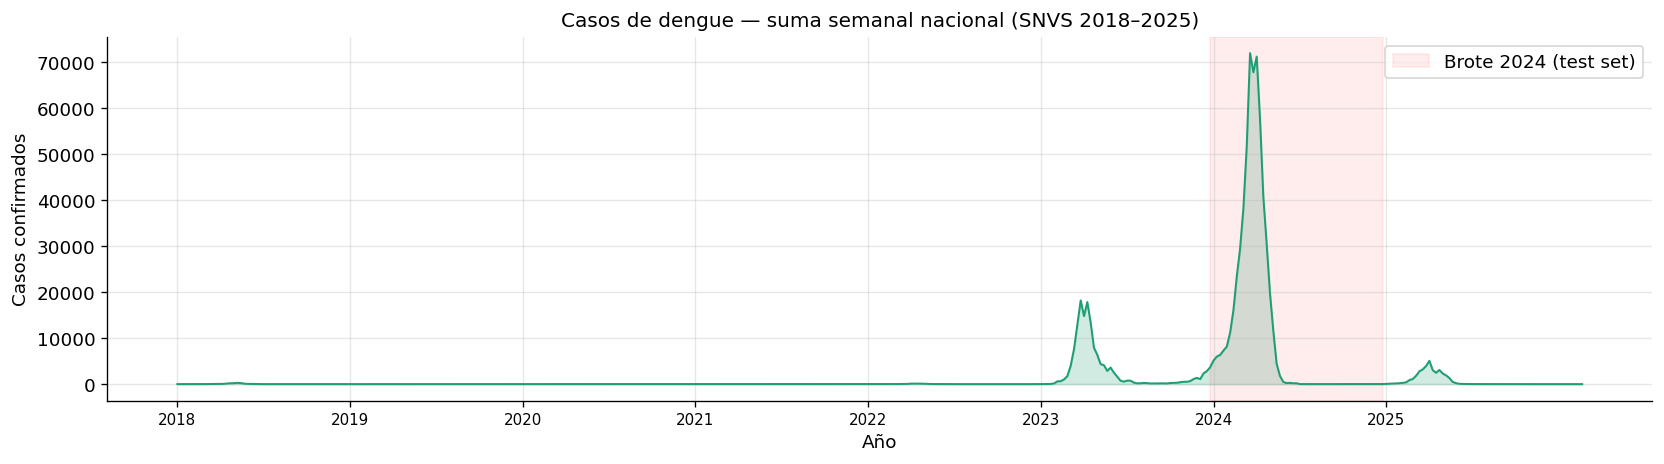

      casos_totales
anio               
2018           1576
2022            802
2023         146876
2024         582265
2025          35153
2026              8


In [18]:
# 10.1 Serie temporal nacional
serie = df_master.groupby(['anio', 'semana'])['cantidad_casos'].sum().reset_index()
serie['t'] = (serie['anio'] - 2018) * 52 + serie['semana']

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(serie['t'], serie['cantidad_casos'], alpha=0.2, color=PALETTE[0])
ax.plot(serie['t'], serie['cantidad_casos'], color=PALETTE[0], lw=1.2)
ax.axvspan(6 * 52, 7 * 52, alpha=0.07, color='red', label='Brote 2024 (test set)')
xticks = [i * 52 + 1 for i in range(8)]
ax.set_xticks(xticks)
ax.set_xticklabels(range(2018, 2026), fontsize=9)
ax.set_xlabel('Año')
ax.set_ylabel('Casos confirmados')
ax.set_title('Casos de dengue — suma semanal nacional (SNVS 2018–2025)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

print(df_master.groupby('anio')['cantidad_casos'].sum().rename('casos_totales').to_frame())

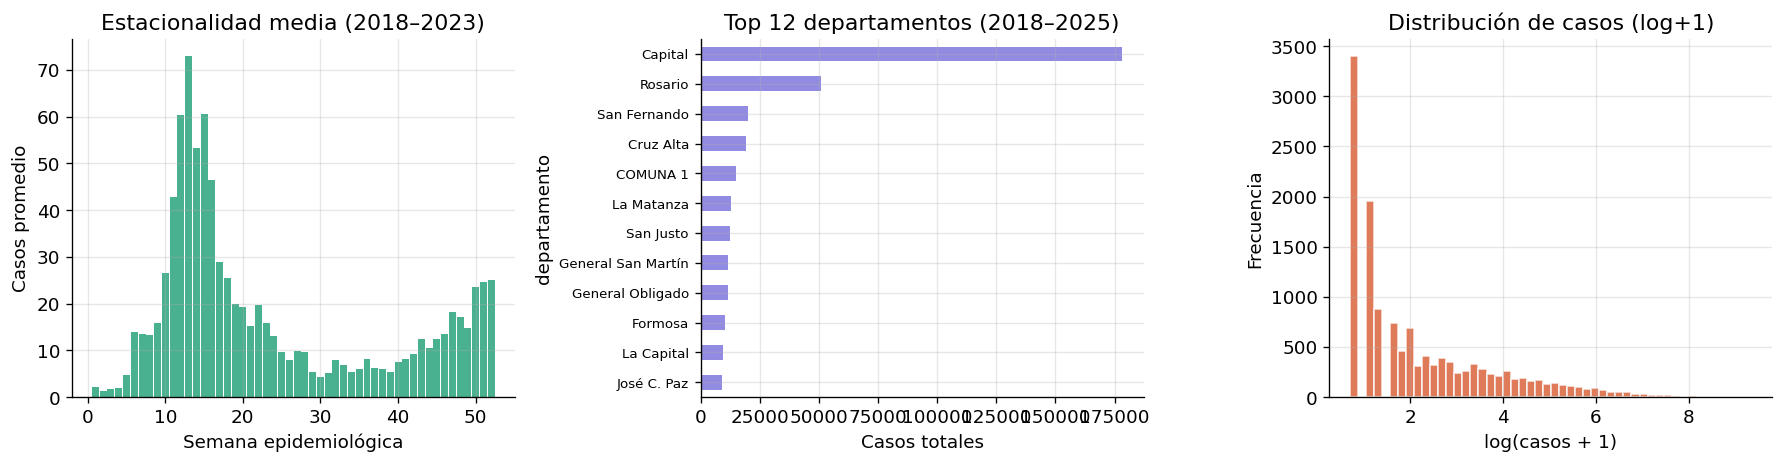

In [19]:
# 10.2 Estacionalidad + top departamentos + distribución
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Estacionalidad (sin 2024 para no distorsionar)
estac = df_master[df_master.anio < 2024].groupby('semana')['cantidad_casos'].mean()
axes[0].bar(estac.index, estac.values, color=PALETTE[0], alpha=0.8, width=0.9)
axes[0].set_title('Estacionalidad media (2018–2023)')
axes[0].set_xlabel('Semana epidemiológica')
axes[0].set_ylabel('Casos promedio')

# Top 12 departamentos
top_d = (df_master[~df_master.departamento.str.lower().isin(['desconocido'])]
               .groupby('departamento')['cantidad_casos']
               .sum().sort_values(ascending=True).tail(12))
top_d.plot(kind='barh', ax=axes[1], color=PALETTE[1], alpha=0.85)
axes[1].set_title('Top 12 departamentos (2018–2025)')
axes[1].set_xlabel('Casos totales')
axes[1].tick_params(axis='y', labelsize=8)

# Distribución log
vals = df_master[df_master.cantidad_casos > 0]['cantidad_casos']
axes[2].hist(np.log1p(vals), bins=50, color=PALETTE[2], alpha=0.8, edgecolor='white')
axes[2].set_title('Distribución de casos (log+1)')
axes[2].set_xlabel('log(casos + 1)')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

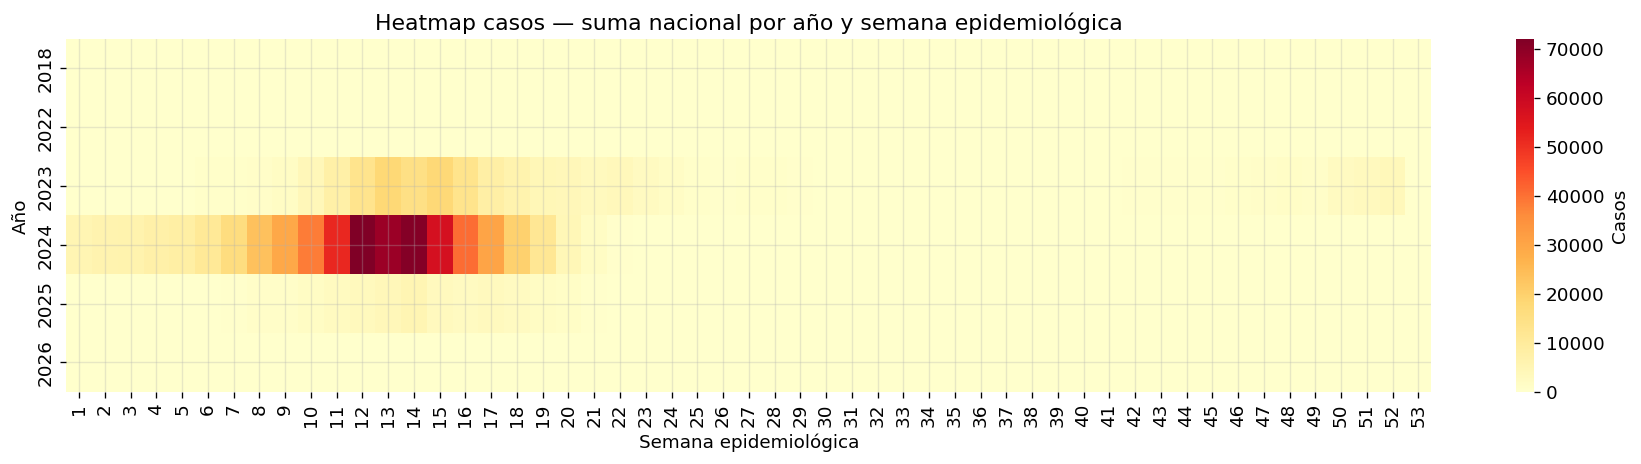

In [20]:
# 10.3 Heatmap año × semana
pivot = (df_master.groupby(['anio', 'semana'])['cantidad_casos']
               .sum().unstack('semana').fillna(0))

fig, ax = plt.subplots(figsize=(15, 4))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0, cbar_kws={'label': 'Casos'})
ax.set_title('Heatmap casos — suma nacional por año y semana epidemiológica')
ax.set_xlabel('Semana epidemiológica')
ax.set_ylabel('Año')
plt.tight_layout()
plt.show()

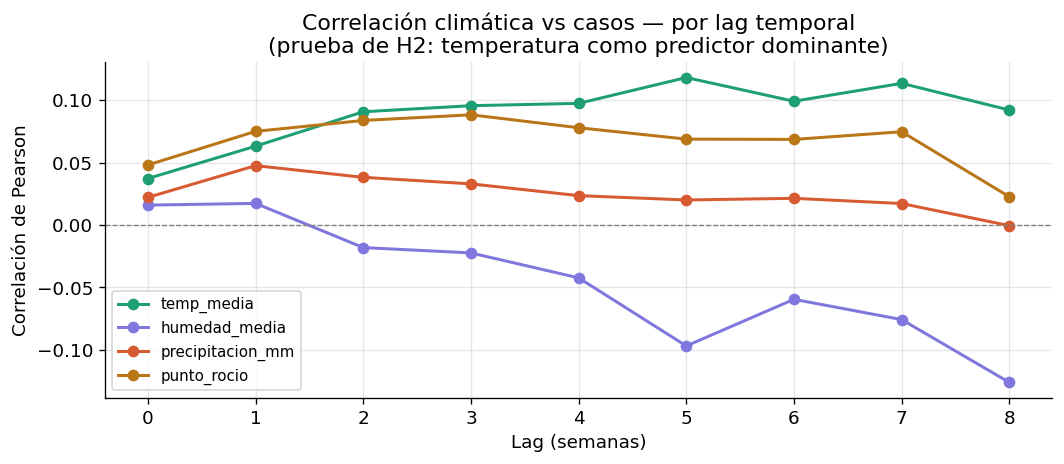

Lag óptimo para temp_media: 5 semanas (correlación = 0.118)


In [21]:
# 10.4 Correlación clima × casos por lag (hipótesis H2)
lag_range  = range(0, 9)
clima_corr = ['temp_media', 'humedad_media', 'precipitacion_mm', 'punto_rocio']
clima_corr = [v for v in clima_corr if v in df_master.columns]

df_sorted = df_master.sort_values(['departamento', 'anio', 'semana'])
corr_df   = pd.DataFrame(index=lag_range, columns=clima_corr, dtype=float)

for lag in lag_range:
    for var in clima_corr:
        shifted = df_sorted.groupby('departamento')[var].shift(lag)
        corr_df.loc[lag, var] = shifted.corr(df_sorted['cantidad_casos'])

fig, ax = plt.subplots(figsize=(9, 4))
for i, var in enumerate(clima_corr):
    ax.plot(corr_df.index, corr_df[var].astype(float), marker='o',
            label=var, color=PALETTE[i], lw=1.8)
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Lag (semanas)')
ax.set_ylabel('Correlación de Pearson')
ax.set_title('Correlación climática vs casos — por lag temporal\n(prueba de H2: temperatura como predictor dominante)')
ax.legend(fontsize=9)
ax.set_xticks(list(lag_range))
plt.tight_layout()
plt.show()

lag_optimo = corr_df['temp_media'].astype(float).idxmax()
print(f'Lag óptimo para temp_media: {lag_optimo} semanas (correlación = {corr_df.loc[lag_optimo, "temp_media"]:.3f})')

---
<a id="features"></a>

## 11. Feature engineering

Se construyen tres familias de features según la literatura revisada (Mussumeci & Coelho, 2020; Sebastianelli et al., 2024):

1. **Lags epidemiológicos** — casos en t−1 a t−4 semanas
2. **Clima rezagado** — temperatura, humedad, precipitación en t−2, t−4, t−6 semanas
3. **Features cíclicas y contextuales** — sin/cos semana, indicador verano austral

In [22]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Construye features para el modelo de predicción de dengue.
    Agrupa por (provincia, departamento) para evitar mezcla entre
    departamentos homónimos de distintas provincias.
    """
    df = df.sort_values(['provincia', 'departamento', 'anio', 'semana']).copy()
    g  = df.groupby(['provincia', 'departamento'])

    # Lags epidemiológicos
    for lag in [1, 2, 3, 4]:
        df[f'casos_lag{lag}'] = g['cantidad_casos'].shift(lag)

    # Media móvil 4 SE (baseline)
    df['casos_ma4'] = g['cantidad_casos'].transform(
        lambda x: x.shift(1).rolling(4, min_periods=1).mean()
    )

    # Clima rezagado
    for var in ['temp_media', 'temp_max', 'humedad_media', 'precipitacion_mm']:
        if var not in df.columns:
            continue
        for lag in [2, 4, 6]:
            df[f'{var}_lag{lag}'] = g[var].shift(lag)

    if 'punto_rocio' in df.columns:
        df['punto_rocio_lag2'] = g['punto_rocio'].shift(2)
        df['punto_rocio_lag4'] = g['punto_rocio'].shift(4)

    if 'humedad_suelo' in df.columns:
        df['humedad_suelo_lag2'] = g['humedad_suelo'].shift(2)

    if 'temp_media' in df.columns:
        df['gdd_lag2'] = g['temp_media'].transform(
            lambda x: x.shift(2).rolling(3, min_periods=1).mean()
        )

    if 'precipitacion_mm' in df.columns:
        df['precip_acum3_lag2'] = g['precipitacion_mm'].transform(
            lambda x: x.shift(2).rolling(3, min_periods=1).sum()
        )

    df['semana_sin'] = np.sin(2 * np.pi * df['semana'] / 52)
    df['semana_cos'] = np.cos(2 * np.pi * df['semana'] / 52)
    df['es_verano']  = df['semana'].apply(lambda w: 1 if (w <= 15 or w >= 45) else 0)

    # Código único por (provincia, departamento)
    df['depto_code'] = (df['provincia'].astype(str) + '_' + df['departamento'].astype(str)) \
                        .astype('category').cat.codes.astype(int)
    return df


# ── Definición de features y target ──────────────────────────────────────────
CANDIDATES = [
    'casos_lag1', 'casos_lag2', 'casos_lag3', 'casos_lag4',
    # casos_ma4 va solo en METADATA_COLS, NO en features del modelo
    'temp_media_lag2', 'temp_media_lag4', 'temp_media_lag6',
    'temp_max_lag2', 'temp_max_lag4',
    'humedad_media_lag2', 'humedad_media_lag4',
    'precipitacion_mm_lag2', 'precipitacion_mm_lag4',
    'precip_acum3_lag2', 'gdd_lag2',
    'punto_rocio_lag2', 'punto_rocio_lag4',
    'humedad_suelo_lag2',
    'semana_sin', 'semana_cos', 'es_verano', 'depto_code',
]
TARGET        = 'cantidad_casos'
METADATA_COLS = ['anio', 'semana', 'departamento', 'provincia', 'casos_ma4']

# ── Construcción del dataset modelable ───────────────────────────────────────
df_feat      = build_features(df_modelado)
FEATURE_COLS = [f for f in CANDIDATES if f in df_feat.columns]
df_model     = df_feat[FEATURE_COLS + [TARGET] + METADATA_COLS].dropna()

assert df_model.columns.duplicated().sum() == 0, "Hay columnas duplicadas en df_model"

print(f'✅ Dataset modelable: {len(df_model):,} filas | {len(FEATURE_COLS)} features')
print(f'   Burn-in eliminado (NaN por lags): {len(df_feat) - len(df_model):,} filas')
print(f'   Features: {FEATURE_COLS}')

✅ Dataset modelable: 6,273 filas | 22 features
   Burn-in eliminado (NaN por lags): 2,534 filas
   Features: ['casos_lag1', 'casos_lag2', 'casos_lag3', 'casos_lag4', 'temp_media_lag2', 'temp_media_lag4', 'temp_media_lag6', 'temp_max_lag2', 'temp_max_lag4', 'humedad_media_lag2', 'humedad_media_lag4', 'precipitacion_mm_lag2', 'precipitacion_mm_lag4', 'precip_acum3_lag2', 'gdd_lag2', 'punto_rocio_lag2', 'punto_rocio_lag4', 'humedad_suelo_lag2', 'semana_sin', 'semana_cos', 'es_verano', 'depto_code']


---
<a id="modelos"></a>

## 12. Modelo baseline y modelo candidato

- **Baseline:** media móvil de 4 SE (comparador)
- **Modelo v1:** Random Forest (300 árboles)
- **Modelo v2:** XGBoost (500 estimadores)
- **Test set:** brote 2024

In [23]:
def mape(y_true: np.ndarray, y_pred: np.ndarray, min_casos: int = 5) -> float:
    """MAPE excluyendo observaciones con menos de min_casos (denominador inestable)."""
    mask = y_true >= min_casos
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


# ── Partición temporal ────────────────────────────────────────────────────────
train = df_model[df_model['anio'] < 2024]
test  = df_model[df_model['anio'] == 2024]

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET].values
y_baseline       = test['casos_ma4'].to_numpy().ravel()

assert len(y_test) == len(y_baseline), \
    f"Tamaños distintos: y_test={len(y_test)}, y_baseline={len(y_baseline)}"

print(f'Train: {len(train):,} filas | Test: {len(test):,} filas')

# ── Baseline ──────────────────────────────────────────────────────────────────
mae_bl  = mean_absolute_error(y_test, y_baseline)
mape_bl = mape(y_test, y_baseline)

# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=300, max_depth=10,
                            min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_rf    = np.clip(rf.predict(X_test), 0, None)
mae_rf  = mean_absolute_error(y_test, y_rf)
mape_rf = mape(y_test, y_rf)

# ── XGBoost ───────────────────────────────────────────────────────────────────
xgb_model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    objective='reg:squarederror', random_state=42, n_jobs=-1, verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_xgb    = np.clip(xgb_model.predict(X_test), 0, None)
mae_xgb  = mean_absolute_error(y_test, y_xgb)
mape_xgb = mape(y_test, y_xgb)

# ── Tabla comparativa ─────────────────────────────────────────────────────────
resultados = pd.DataFrame({
    'Modelo':   ['Baseline (MA4)', 'Random Forest', 'XGBoost'],
    'MAE':      [mae_bl,  mae_rf,  mae_xgb],
    'MAPE (%)': [mape_bl, mape_rf, mape_xgb],
    'Objetivo MAPE ≤ 30%': [
        '—',
        '✅' if mape_rf  <= 30 else '❌',
        '✅' if mape_xgb <= 30 else '❌',
    ]
})
print('=== Resultados en test set (brote 2024) ===')
print(resultados.to_string(index=False))

Train: 2,597 filas | Test: 3,477 filas
=== Resultados en test set (brote 2024) ===
        Modelo    MAE  MAPE (%) Objetivo MAPE ≤ 30%
Baseline (MA4) 88.573   132.265                   —
 Random Forest 53.496    62.626                   ❌
       XGBoost 61.543    83.624                   ❌


---
<a id="validacion"></a>

## 13. Validación walk-forward

In [24]:
wf_results = []
eval_years = [y for y in sorted(df_model.anio.unique()) if y >= 2020]

for pred_year in eval_years:
    tr = df_model[df_model['anio'] < pred_year]
    te = df_model[df_model['anio'] == pred_year]
    if len(tr) < 100 or len(te) == 0:
        continue

    # Random Forest
    m_rf = RandomForestRegressor(n_estimators=150, max_depth=8,
                                  min_samples_leaf=5, random_state=42, n_jobs=-1)
    m_rf.fit(tr[FEATURE_COLS], tr[TARGET])
    pred_rf = np.clip(m_rf.predict(te[FEATURE_COLS]), 0, None)

    # XGBoost
    m_xgb = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6,
                               subsample=0.8, random_state=42, n_jobs=-1, verbosity=0)
    m_xgb.fit(tr[FEATURE_COLS], tr[TARGET])
    pred_xgb = np.clip(m_xgb.predict(te[FEATURE_COLS]), 0, None)

    wf_results.append({
        'año':          pred_year,
        'n_obs':        len(te),
        'mape_baseline':mape(te[TARGET].values, te['casos_ma4'].values),
        'mape_rf':      mape(te[TARGET].values, pred_rf),
        'mape_xgb':     mape(te[TARGET].values, pred_xgb),
        'mae_rf':       mean_absolute_error(te[TARGET], pred_rf),
        'mae_xgb':      mean_absolute_error(te[TARGET], pred_xgb),
    })
    print(f'  {pred_year}: baseline {wf_results[-1]["mape_baseline"]:.1f}% | RF {wf_results[-1]["mape_rf"]:.1f}% | XGB {wf_results[-1]["mape_xgb"]:.1f}%')

df_wf = pd.DataFrame(wf_results)
df_wf['mejora_rf_pp']  = df_wf['mape_baseline'] - df_wf['mape_rf']
df_wf['mejora_xgb_pp'] = df_wf['mape_baseline'] - df_wf['mape_xgb']

  2024: baseline 132.3% | RF 61.7% | XGB 66.3%
  2025: baseline 56.9% | RF 51.3% | XGB 43.6%


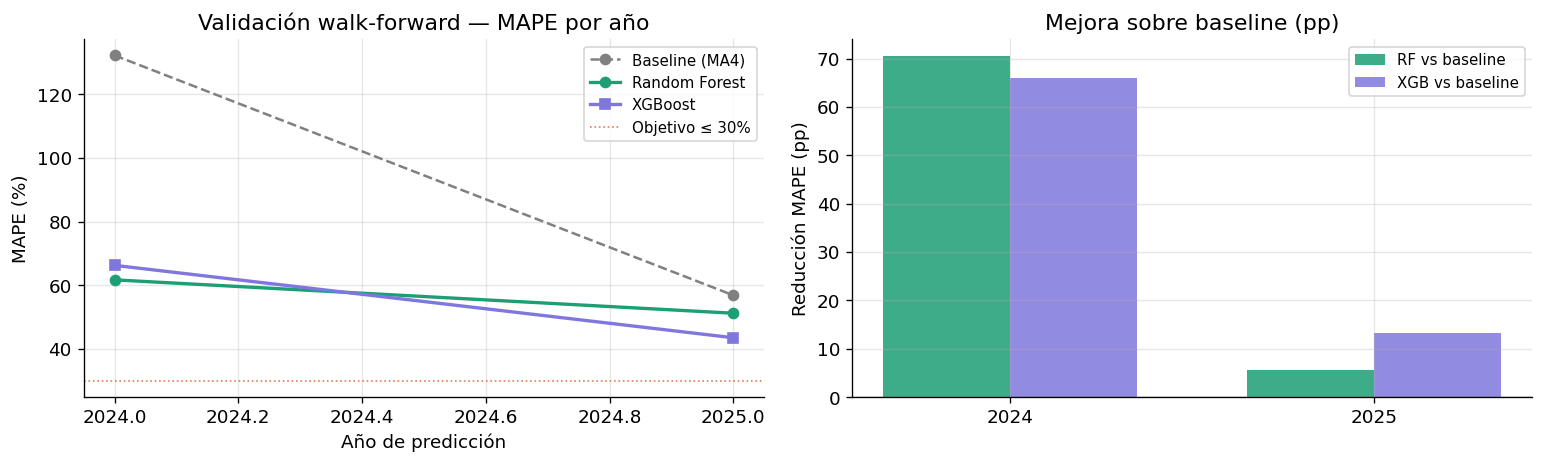

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(df_wf['año'], df_wf['mape_baseline'], 'o--', color='gray',   label='Baseline (MA4)', lw=1.5)
axes[0].plot(df_wf['año'], df_wf['mape_rf'],       'o-',  color=PALETTE[0], label='Random Forest', lw=2)
axes[0].plot(df_wf['año'], df_wf['mape_xgb'],      's-',  color=PALETTE[1], label='XGBoost',       lw=2)
axes[0].axhline(30, color=PALETTE[2], lw=1, ls=':', alpha=0.8, label='Objetivo ≤ 30%')
axes[0].set_xlabel('Año de predicción')
axes[0].set_ylabel('MAPE (%)')
axes[0].set_title('Validación walk-forward — MAPE por año')
axes[0].legend(fontsize=9)

x = np.arange(len(df_wf))
w = 0.35
axes[1].bar(x - w/2, df_wf['mejora_rf_pp'],  w, label='RF vs baseline',  color=PALETTE[0], alpha=0.85)
axes[1].bar(x + w/2, df_wf['mejora_xgb_pp'], w, label='XGB vs baseline', color=PALETTE[1], alpha=0.85)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_wf['año'])
axes[1].set_ylabel('Reducción MAPE (pp)')
axes[1].set_title('Mejora sobre baseline (pp)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
<a id="resultados"></a>

##  14. Resultados e interpretabilidad

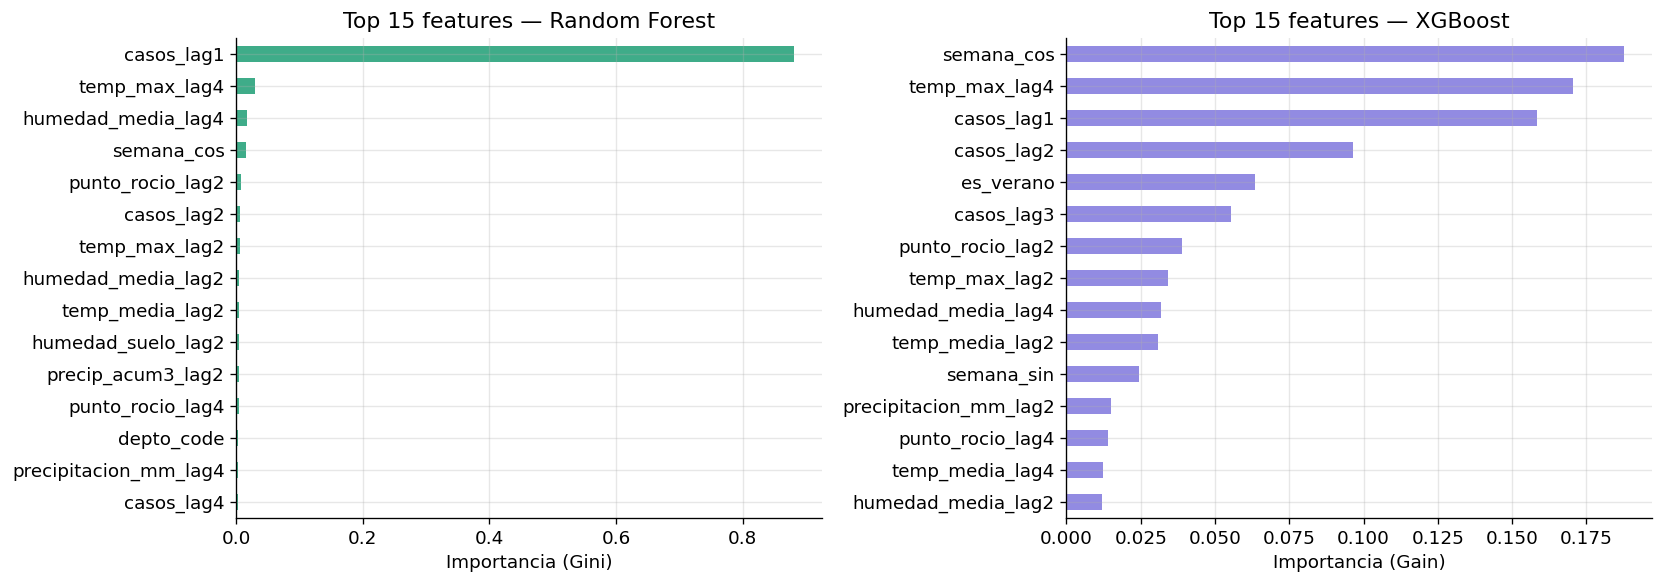

Top 5 RF: ['casos_lag1', 'temp_max_lag4', 'humedad_media_lag4', 'semana_cos', 'punto_rocio_lag2']
Top 5 XGB: ['semana_cos', 'temp_max_lag4', 'casos_lag1', 'casos_lag2', 'es_verano']


In [26]:
# Importancia de features — Random Forest
imp_rf = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

# Importancia XGBoost
imp_xgb = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

imp_rf.tail(15).plot(kind='barh', ax=axes[0], color=PALETTE[0], alpha=0.85)
axes[0].set_xlabel('Importancia (Gini)')
axes[0].set_title('Top 15 features — Random Forest')

imp_xgb.tail(15).plot(kind='barh', ax=axes[1], color=PALETTE[1], alpha=0.85)
axes[1].set_xlabel('Importancia (Gain)')
axes[1].set_title('Top 15 features — XGBoost')

plt.tight_layout()
plt.show()

print('Top 5 RF:',  imp_rf.tail(5).sort_values(ascending=False).index.tolist())
print('Top 5 XGB:', imp_xgb.tail(5).sort_values(ascending=False).index.tolist())

Departamento con mayor carga en 2024: Capital (120002 casos)


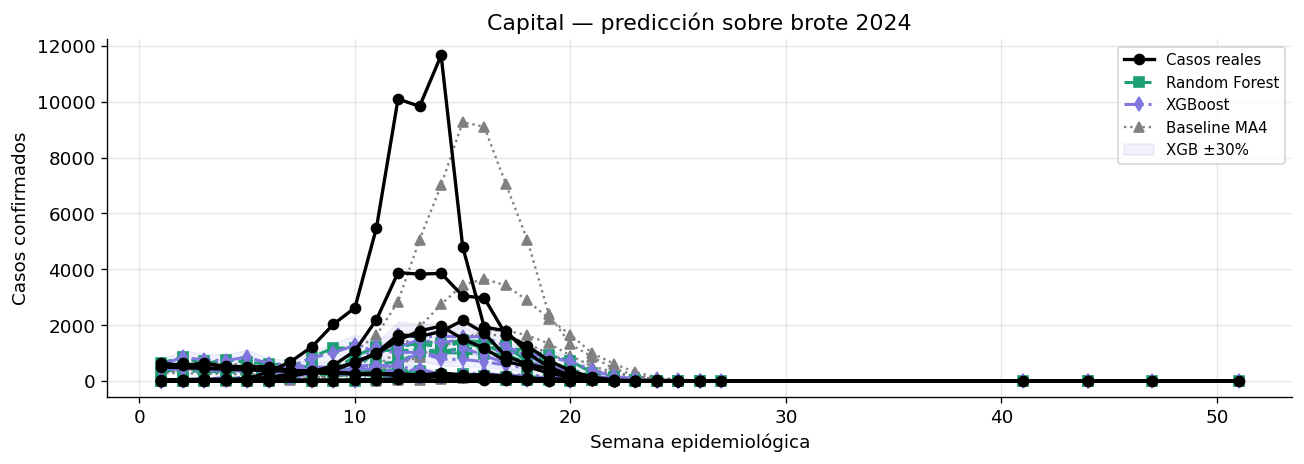

In [27]:
# Predicción vs real — departamento de mayor carga 2024
deptos_2024 = test.groupby('departamento')[TARGET].sum().sort_values(ascending=False)
depto_foco  = deptos_2024.index[0]
print(f'Departamento con mayor carga en 2024: {depto_foco} ({deptos_2024.iloc[0]:.0f} casos)')

mask      = test['departamento'] == depto_foco
sem_d     = test.loc[mask, 'semana'].values
y_real_d  = y_test[mask.values]
y_rf_d    = y_rf[mask.values]
y_xgb_d   = y_xgb[mask.values]
y_base_d  = y_baseline[mask.values]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(sem_d, y_real_d, 'o-', color='black',    lw=2,   label='Casos reales',  zorder=4)
ax.plot(sem_d, y_rf_d,   's--', color=PALETTE[0], lw=1.8, label='Random Forest', zorder=3)
ax.plot(sem_d, y_xgb_d,  'd-.', color=PALETTE[1], lw=1.8, label='XGBoost',       zorder=3)
ax.plot(sem_d, y_base_d, '^:',  color='gray',     lw=1.4, label='Baseline MA4',   zorder=2)
ax.fill_between(sem_d, y_xgb_d * 0.7, y_xgb_d * 1.3, alpha=0.1, color=PALETTE[1], label='XGB ±30%')
ax.set_xlabel('Semana epidemiológica')
ax.set_ylabel('Casos confirmados')
ax.set_title(f'{depto_foco} — predicción sobre brote 2024')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [28]:
# Resumen final del estado del proyecto
print('═' * 60)
print('RESUMEN FINAL — ESTADO DEL PROYECTO')
print('═' * 60)
print(f'Dataset SNVS (filas limpias)    : {len(df_master):,}')
print(f'Total casos 2018–2025           : {df_master.cantidad_casos.sum():,}')
print(f'Departamentos modelados         : {df_model.departamento.nunique()}')
print(f'Features construidas            : {len(FEATURE_COLS)}')
print()
print(f'Resultados en test set (2024):')
print(f'  Baseline (MA4)   MAPE = {mape_bl:.1f}%')
print(f'  Random Forest    MAPE = {mape_rf:.1f}%   (mejora: {mape_bl - mape_rf:+.1f} pp)')
print(f'  XGBoost          MAPE = {mape_xgb:.1f}%   (mejora: {mape_bl - mape_xgb:+.1f} pp)')
print()
print('Próximos pasos:')
print('  1. Conectar NASA POWER real (descomentar Opción A sección 7)')
print('  2. Incorporar NDVI via Google Earth Engine (Sentinel-2)')
print('  3. Agregar NBI y densidad del Censo 2022')
print('  4. Implementar corrección de subregistro (~1.5×)')
print('  5. Análisis regional NOA vs pampeana vs NEA (H3)')
print('  6. Evaluación de alerta binaria (F1, precisión) para operaciones')

════════════════════════════════════════════════════════════
RESUMEN FINAL — ESTADO DEL PROYECTO
════════════════════════════════════════════════════════════
Dataset SNVS (filas limpias)    : 13,599
Total casos 2018–2025           : 766,680
Departamentos modelados         : 147
Features construidas            : 22

Resultados en test set (2024):
  Baseline (MA4)   MAPE = 132.3%
  Random Forest    MAPE = 62.6%   (mejora: +69.6 pp)
  XGBoost          MAPE = 83.6%   (mejora: +48.6 pp)

Próximos pasos:
  1. Conectar NASA POWER real (descomentar Opción A sección 7)
  2. Incorporar NDVI via Google Earth Engine (Sentinel-2)
  3. Agregar NBI y densidad del Censo 2022
  4. Implementar corrección de subregistro (~1.5×)
  5. Análisis regional NOA vs pampeana vs NEA (H3)
  6. Evaluación de alerta binaria (F1, precisión) para operaciones


In [29]:
# ============================================================
# TABLERO DE RIESGO DE DENGUE: PROVINCIAS + MAPA + BIO WIKIPEDIA + KPIs
# ============================================================
# Requiere:
# - que ya exista el DataFrame pandas: df_riesgo_provincial
#   con columnas como:
#   ranking, provincia, region, casos_2024, tasa_incidencia,
#   riesgo_climatico, indice_vs_promedio
#
# Este bloque:
# 1) toma las provincias del tablero de riesgo
# 2) busca imagen y resumen desde Wikipedia/Wikimedia
# 3) arma tarjetas HTML animadas estilo revista digital
# 4) muestra mapa conceptual + bio + métricas epidemiológicas
# ============================================================

import pandas as pd
import requests
import html
from IPython.display import display, HTML

# ------------------------------------------------------------
# 1) Mapeo de provincias hacia páginas razonables de Wikipedia
#    para obtener imagen y biografía introductoria.
# ------------------------------------------------------------
wiki_map = {
    "Buenos Aires": "Buenos_Aires_Province",
    "Santa Fe": "Santa_Fe_Province",
    "Córdoba": "Córdoba_Province,_Argentina",
    "Salta": "Salta_Province",
    "Jujuy": "Jujuy_Province",
    "Tucumán": "Tucumán_Province",
    "Mendoza": "Mendoza_Province",
    "Entre Ríos": "Entre_Ríos_Province",
    "Chaco": "Chaco_Province",
    "Corrientes": "Corrientes_Province"
}

# ------------------------------------------------------------
# 2) Función para traer resumen e imagen principal desde
#    la API REST pública de Wikipedia.
# ------------------------------------------------------------
def obtener_info_wikipedia(page_title):
    """
    Devuelve:
    - title: título encontrado
    - extract: resumen corto
    - image: URL de imagen principal si existe
    - url: link al artículo
    """
    url = f"https://en.wikipedia.org/api/rest_v1/page/summary/{page_title}"
    headers = {
        "User-Agent": "Mozilla/5.0 (compatible; TableroDengueBot/1.0)"
    }

    try:
        r = requests.get(url, headers=headers, timeout=15)
        if r.status_code != 200:
            return {
                "title": page_title.replace("_", " "),
                "extract": "No se pudo recuperar la información en este momento.",
                "image": "",
                "url": f"https://en.wikipedia.org/wiki/{page_title}"
            }

        data = r.json()

        title = data.get("title", page_title.replace("_", " "))
        extract = data.get("extract", "Sin resumen disponible.")
        image = ""

        if "originalimage" in data:
            image = data["originalimage"].get("source", "")
        elif "thumbnail" in data:
            image = data["thumbnail"].get("source", "")

        wiki_url = data.get("content_urls", {}).get("desktop", {}).get(
            "page",
            f"https://en.wikipedia.org/wiki/{page_title}"
        )

        return {
            "title": title,
            "extract": extract,
            "image": image,
            "url": wiki_url
        }

    except Exception:
        return {
            "title": page_title.replace("_", " "),
            "extract": "No se pudo recuperar la información en este momento.",
            "image": "",
            "url": f"https://en.wikipedia.org/wiki/{page_title}"
        }

# ------------------------------------------------------------
# 3) Placeholder visual por si una provincia no trae imagen.
# ------------------------------------------------------------
def placeholder_image(text):
    safe = text.replace(" ", "+")
    return f"https://placehold.co/800x600/2E8B57/FFFFFF?text={safe}"

# ------------------------------------------------------------
# 4) DataFrame simulado de riesgo provincial de dengue
# ------------------------------------------------------------
df_riesgo_provincial = pd.DataFrame({
    "ranking": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "provincia": ["Buenos Aires", "Santa Fe", "Córdoba", "Salta", "Jujuy", "Tucumán", "Mendoza", "Entre Ríos", "Chaco", "Corrientes"],
    "region": ["Pampeana", "Pampeana", "Pampeana", "NOA", "NOA", "NOA", "Cuyo", "Mesopotamia", "NEA", "NEA"],
    "casos_2024": [150000, 80000, 60000, 45000, 40000, 35000, 25000, 20000, 18000, 15000],
    "tasa_incidencia": [450.5, 380.2, 320.1, 890.3, 1200.5, 950.7, 180.4, 290.8, 650.2, 580.9],
    "riesgo_climatico": [0.75, 0.68, 0.62, 0.85, 0.92, 0.88, 0.45, 0.55, 0.78, 0.72],
    "indice_vs_promedio": [2.1, 1.8, 1.5, 4.2, 5.7, 4.5, 0.9, 1.4, 3.1, 2.8]
})

# ------------------------------------------------------------
# 5) Se arma una tabla enriquecida con biografía e imagen.
# ------------------------------------------------------------
cards_data = []

for _, row in df_riesgo_provincial.iterrows():
    provincia = row["provincia"]
    wiki_title = wiki_map.get(provincia, provincia.replace(" ", "_"))
    info = obtener_info_wikipedia(wiki_title)

    cards_data.append({
        "ranking": int(row["ranking"]),
        "provincia": str(row["provincia"]),
        "region": str(row["region"]),
        "casos_2024": int(row["casos_2024"]),
        "tasa_incidencia": float(row["tasa_incidencia"]),
        "riesgo_climatico": float(row["riesgo_climatico"]),
        "indice_vs_promedio": float(row["indice_vs_promedio"]),
        "wiki_title": info["title"],
        "bio": info["extract"],
        "image": info["image"] if info["image"] else placeholder_image(provincia),
        "url": info["url"]
    })

# ------------------------------------------------------------
# 6) Formateadores útiles.
# ------------------------------------------------------------
def fmt_int(x):
    return f"{x:,}".replace(",", ".")

def fmt_float(x):
    return f"{x:.1f}"

# ------------------------------------------------------------
# 7) Se genera el HTML completo.
# ------------------------------------------------------------
cards_html = ""

for item in cards_data:
    provincia = html.escape(item["provincia"])
    region = html.escape(item["region"])
    wiki_title = html.escape(item["wiki_title"])
    bio = html.escape(item["bio"])
    image = html.escape(item["image"])
    url = html.escape(item["url"])

    ranking = item["ranking"]
    casos = fmt_int(item["casos_2024"])
    tasa = fmt_float(item["tasa_incidencia"])
    riesgo = fmt_float(item["riesgo_climatico"])
    indice = fmt_float(item["indice_vs_promedio"])

    bar_width = min(max(item["riesgo_climatico"] * 100, 0), 100)

    cards_html += f"""
    <article class="mag-card reveal">
        <div class="mag-left">
            <div class="img-wrap">
                <img src="{image}" alt="{provincia}">
                <div class="img-overlay"></div>
                <div class="rank-badge">#{ranking}</div>
                <div class="topic-chip">{region}</div>
            </div>
        </div>

        <div class="mag-right">
            <div class="headline-row">
                <div>
                    <div class="kicker">Provincia en riesgo</div>
                    <h2>{provincia}</h2>
                    <div class="wiki-ref">
                        Información geográfica: <a href="{url}" target="_blank">{wiki_title}</a>
                    </div>
                </div>
            </div>

            <div class="bio-box">
                <p class="bio-text">{bio}</p>
            </div>

            <div class="metrics-grid">
                <div class="metric-card">
                    <span class="metric-label">Casos 2024</span>
                    <span class="metric-value">{casos}</span>
                </div>

                <div class="metric-card">
                    <span class="metric-label">Tasa incidencia (x100k)</span>
                    <span class="metric-value">{tasa}</span>
                </div>

                <div class="metric-card">
                    <span class="metric-label">Riesgo climático</span>
                    <span class="metric-value">{riesgo}</span>
                </div>

                <div class="metric-card">
                    <span class="metric-label">Índice vs promedio</span>
                    <span class="metric-value">{indice}x</span>
                </div>
            </div>

            <div class="progress-block">
                <div class="progress-header">
                    <span>Riesgo climático relativo</span>
                    <span>{riesgo}</span>
                </div>
                <div class="progress-track">
                    <div class="progress-fill" style="width:{bar_width}%;"></div>
                </div>
            </div>
        </div>
    </article>
    """

html_final = f"""
<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>Tablero de Riesgo de Dengue</title>
<style>
    * {{
        box-sizing: border-box;
    }}

    body {{
        margin: 0;
        padding: 0;
        background:
            radial-gradient(circle at top left, rgba(46,139,87,0.18), transparent 25%),
            radial-gradient(circle at top right, rgba(255,69,0,0.16), transparent 28%),
            linear-gradient(180deg, #0a1a0a 0%, #1a2a1a 100%);
        color: #f0f8f0;
        font-family: "Inter", "Segoe UI", Arial, sans-serif;
    }}

    .page {{
        max-width: 1400px;
        margin: 0 auto;
        padding: 32px 18px 60px 18px;
    }}

    .hero {{
        margin-bottom: 28px;
        padding: 28px;
        border: 1px solid rgba(255,255,255,0.08);
        border-radius: 24px;
        background: linear-gradient(135deg, rgba(46,139,87,0.05), rgba(255,255,255,0.02));
        backdrop-filter: blur(10px);
        box-shadow: 0 20px 50px rgba(0,0,0,0.35);
        overflow: hidden;
        position: relative;
    }}

    .hero::before {{
        content: "";
        position: absolute;
        inset: -20%;
        background:
            radial-gradient(circle, rgba(46, 139, 87, 0.12), transparent 30%);
        animation: pulseGlow 7s infinite ease-in-out;
        pointer-events: none;
    }}

    .eyebrow {{
        text-transform: uppercase;
        letter-spacing: 0.18em;
        font-size: 11px;
        color: #32cd32;
        margin-bottom: 10px;
        font-weight: 700;
    }}

    .hero h1 {{
        margin: 0 0 10px 0;
        font-size: clamp(30px, 5vw, 56px);
        line-height: 1.05;
        font-weight: 900;
    }}

    .hero p {{
        margin: 0;
        max-width: 980px;
        font-size: 16px;
        line-height: 1.7;
        color: #c8d5c8;
    }}

    .cards-wrap {{
        display: grid;
        gap: 24px;
    }}

    .mag-card {{
        display: grid;
        grid-template-columns: 340px 1fr;
        gap: 22px;
        padding: 20px;
        border-radius: 28px;
        background: linear-gradient(180deg, rgba(46,139,87,0.045), rgba(255,255,255,0.02));
        border: 1px solid rgba(46,139,87,0.08);
        box-shadow: 0 25px 60px rgba(0,0,0,0.28);
        overflow: hidden;
        position: relative;
        transform: translateY(18px);
        opacity: 0;
        animation: riseIn .9s ease forwards;
    }}

    .mag-card:nth-child(1) {{ animation-delay: .08s; }}
    .mag-card:nth-child(2) {{ animation-delay: .16s; }}
    .mag-card:nth-child(3) {{ animation-delay: .24s; }}
    .mag-card:nth-child(4) {{ animation-delay: .32s; }}
    .mag-card:nth-child(5) {{ animation-delay: .40s; }}
    .mag-card:nth-child(6) {{ animation-delay: .48s; }}
    .mag-card:nth-child(7) {{ animation-delay: .56s; }}
    .mag-card:nth-child(8) {{ animation-delay: .64s; }}
    .mag-card:nth-child(9) {{ animation-delay: .72s; }}
    .mag-card:nth-child(10) {{ animation-delay: .80s; }}

    .img-wrap {{
        position: relative;
        width: 100%;
        height: 100%;
        min-height: 360px;
        border-radius: 22px;
        overflow: hidden;
        border: 1px solid rgba(46,139,87,0.07);
        background: #0a1a0a;
    }}

    .img-wrap img {{
        width: 100%;
        height: 100%;
        object-fit: cover;
        display: block;
        transform: scale(1.02);
        transition: transform 0.6s ease;
    }}

    .mag-card:hover .img-wrap img {{
        transform: scale(1.08);
    }}

    .img-overlay {{
        position: absolute;
        inset: 0;
        background: linear-gradient(
            180deg,
            rgba(0,0,0,0.00) 0%,
            rgba(0,0,0,0.12) 50%,
            rgba(0,0,0,0.55) 100%
        );
    }}

    .rank-badge {{
        position: absolute;
        top: 14px;
        left: 14px;
        padding: 8px 12px;
        border-radius: 999px;
        background: rgba(46,139,87,0.12);
        border: 1px solid rgba(46,139,87,0.18);
        font-weight: 800;
        font-size: 14px;
        backdrop-filter: blur(8px);
    }}

    .topic-chip {{
        position: absolute;
        bottom: 14px;
        left: 14px;
        padding: 8px 12px;
        border-radius: 999px;
        background: rgba(255,69,0,0.18);
        border: 1px solid rgba(255,69,0,0.32);
        color: #ffe4e1;
        font-size: 12px;
        font-weight: 700;
        letter-spacing: .02em;
    }}

    .mag-right {{
        display: flex;
        flex-direction: column;
        justify-content: center;
    }}

    .kicker {{
        color: #32cd32;
        font-weight: 800;
        font-size: 12px;
        text-transform: uppercase;
        letter-spacing: 0.14em;
        margin-bottom: 8px;
    }}

    .headline-row h2 {{
        margin: 0;
        font-size: clamp(26px, 3.2vw, 40px);
        line-height: 1.05;
        font-weight: 900;
    }}

    .wiki-ref {{
        margin-top: 8px;
        font-size: 13px;
        color: #b8c1b1;
    }}

    .wiki-ref a {{
        color: #32cd32;
        text-decoration: none;
        font-weight: 700;
    }}

    .wiki-ref a:hover {{
        text-decoration: underline;
    }}

    .bio-box {{
        margin-top: 18px;
        margin-bottom: 20px;
        position: relative;
        padding: 16px 18px;
        border-radius: 18px;
        background: rgba(46,139,87,0.04);
        border-left: 4px solid #32cd32;
        overflow: hidden;
    }}

    .bio-text {{
        margin: 0;
        color: #e6ebf5;
        font-size: 15px;
        line-height: 1.75;
        animation: fadeText 1.3s ease both;
    }}

    .metrics-grid {{
        display: grid;
        grid-template-columns: repeat(2, minmax(180px, 1fr));
        gap: 14px;
        margin-bottom: 18px;
    }}

    .metric-card {{
        background: rgba(46,139,87,0.05);
        border: 1px solid rgba(46,139,87,0.07);
        border-radius: 18px;
        padding: 16px;
        min-height: 92px;
        display: flex;
        flex-direction: column;
        justify-content: center;
        box-shadow: inset 0 1px 0 rgba(46,139,87,0.04);
    }}

    .metric-label {{
        color: #a9b4a7;
        font-size: 12px;
        text-transform: uppercase;
        letter-spacing: 0.08em;
        margin-bottom: 8px;
        font-weight: 700;
    }}

    .metric-value {{
        color: #ffffff;
        font-size: 28px;
        line-height: 1;
        font-weight: 900;
    }}

    .progress-block {{
        margin-top: 4px;
    }}

    .progress-header {{
        display: flex;
        justify-content: space-between;
        align-items: center;
        margin-bottom: 8px;
        font-size: 13px;
        color: #c8d0cf;
        font-weight: 700;
    }}

    .progress-track {{
        width: 100%;
        height: 16px;
        background: rgba(46,139,87,0.06);
        border-radius: 999px;
        overflow: hidden;
        border: 1px solid rgba(46,139,87,0.08);
    }}

    .progress-fill {{
        height: 100%;
        border-radius: 999px;
        background: linear-gradient(90deg, #32cd32 0%, #ff4500 100%);
        box-shadow: 0 0 20px rgba(50,205,50,0.35);
        animation: growBar 1.3s ease;
    }}

    @keyframes riseIn {{
        from {{
            opacity: 0;
            transform: translateY(22px);
        }}
        to {{
            opacity: 1;
            transform: translateY(0);
        }}
    }}

    @keyframes growBar {{
        from {{ width: 0; }}
    }}

    @keyframes fadeText {{
        from {{
            opacity: 0;
            transform: translateY(8px);
        }}
        to {{
            opacity: 1;
            transform: translateY(0);
        }}
    }}

    @keyframes pulseGlow {{
        0%   {{ transform: scale(1); opacity: .65; }}
        50%  {{ transform: scale(1.08); opacity: .95; }}
        100% {{ transform: scale(1); opacity: .65; }}
    }}

    @media (max-width: 980px) {{
        .mag-card {{
            grid-template-columns: 1fr;
        }}

        .img-wrap {{
            min-height: 300px;
        }}
    }}

    @media (max-width: 640px) {{
        .page {{
            padding: 18px 10px 40px 10px;
        }}

        .hero {{
            padding: 20px;
            border-radius: 20px;
        }}

        .mag-card {{
            padding: 14px;
            border-radius: 22px;
        }}

        .metrics-grid {{
            grid-template-columns: 1fr;
        }}

        .metric-value {{
            font-size: 24px;
        }}
    }}
</style>
</head>
<body>
    <div class="page">
        <section class="hero">
            <div class="eyebrow">Edición interactiva · tablero epidemiológico</div>
            <h1>Provincias en riesgo de dengue</h1>
            <p>
                Un formato visual tipo revista digital que combina mapas conceptuales, contexto geográfico
                y métricas epidemiológicas para comparar el riesgo relativo de cada provincia
                en el contexto del brote de dengue 2024.
            </p>
        </section>

        <section class="cards-wrap">
            {cards_html}
        </section>
    </div>
</body>
</html>
"""

display(HTML(html_final))